In [1]:
from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "/home/shah/projects/DECODE_PLEX/"
path = Path(path).expanduser()
import sys
sys.path.insert(0, str(path))

In [3]:
import decode
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/home/shah/projects/DECODE_PLEX/decode/__init__.py


In [12]:
path_frames_list = ["/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_1",
               # "/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_2",
               # "/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_LowDensity_1",
               #"/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_LowDensity_2",
               #"/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_LowDensity_3",
               #"/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_LowDensity_4",
               # "/home/shah/vbc_share/shah/dual_color/NC240802/2percent/240802_NC_ER_MT_TritonX100_2percent_1",
               "/home/shah/vbc_share/shah/dual_color/NC240802/2percent/240802_NC_ER_MT_TritonX100_2percent_2",
               # "/home/shah/vbc_share/shah/dual_color/NC240802/2percent/240802_NC_ER_MT_TritonX100_2percent_HighDensityUV_3",
               # "/home/shah/vbc_share/shah/dual_color/NC240802/2percent/240802_NC_ER_MT_TritonX100_2percent_HighDensityUV_4",,
               ]




path_training_list = [# "/home/shah/projects/DECODE_PLEX/outputs/experiments/2025-07-27_01-01-smapPSF-smapTrafo",
                 "/home/shah/projects/DECODE_PLEX/outputs/experiments/2025-08-01_15-26-genPSF-beadsTrafo",
                 "/home/shah/projects/DECODE_PLEX/outputs/experiments/2025-08-01_15-17-beadsuiPSF-beadsTrafo"
                 ]

In [ ]:
for path_frames in path_frames_list:
    for path_training in path_training_list:
        path_frames = Path(path_frames).expanduser()
        path_training = Path(path_training).expanduser()
        
        path_cfg = path_training / "param_run.yaml"
        cfg = decode.io.param.load(path_cfg)
        gain_correct = True
        
        path_ckpt = next((path_training).glob("*.ckpt"))
        model_identifier = f"model_{path_ckpt.parent.stem}"
        
        path_trafo = cfg["Paths"]["trafo"]
        path_trafo = Path(path_trafo).expanduser()
        
        if path_trafo.suffix == ".h5":
            print("load .h5 file, setting the transformation matrix!")
            cfg["Test"]["Transformation"]["Pos"]["glob"]["offset"] = {"x": [0, -5], "y": [0, -23], "z": [0, 0]}
        
        path_subs = [sorted(path_frames.glob("*.tif"))[0].parent]

        mode_camera = "rois"
        bulk_load = False 

        for p in path_subs:
            pframe = sorted(p.glob("*.tif"))[0]
            frames = decode.io.frames.load_tif(pframe, auto_ome=True, memmap=True)
            print(f"Paths: \n{pframe}\nsize: {frames.size()}")

            if bulk_load:
                # ToDo: implement bulk for multi-camera
                frames = frames[:]
            # frames = frames[0:1000,:,:]
            frame_size = list(frames.size())
            frame_crop = [math.floor(frame_size[-2] / 8) * 8, math.floor(frame_size[-1] / 8) * 8]
            # max x out at 256
            frame_crop[0] = min(frame_crop[0], 256) 
            print(f"Frame size: {frame_size} -> Crop: {frame_crop}")

            # load metadata
            path_meta = sorted(pframe.parent.glob("*metadata.txt"))[0]
            meta = decode.io.camera.load_metadata(path_meta)
            shift = torch.as_tensor(meta.glob.get_roi_shift(gain_corrected=gain_correct) + [0]) 
            print(f"ROI Shift: {shift}\nMetadata path: {path_meta}")

            path_ckpt = next((path_training).glob("*.ckpt"))
            em_out, logger = infer_func.infer(
                frames,
                frame_crop=frame_crop,
                cfg=cfg,
                model=path_ckpt,
                mode="multi",
                trafo=path_trafo,
                mode_camera=mode_camera,
                roi_shift=shift[:2].tolist(),
                logger="debug",
                batch_size=16,
                num_workers=0,
            )

            em_save = em_out.clone()
            em_save.xyz_px += shift

            # path_out = pframe.parent / f"{pframe.stem}_decode_plex_fit_{model_identifier}.h5"
            path_out = "../data/dual_color_all/" + f"{pframe.stem}_decode_plex_fit_{model_identifier}.h5"
            em_out.save(path_out)
            print(f"Saved to {path_out}")


load .h5 file, setting the transformation matrix!


<tifffile.TiffTag 270 @164961> coercing invalid ASCII to bytes, due to UnicodeDecodeError('charmap', b'V\x07@\x08\xc4\t\x87\x07\x05\nw\n\xe6\n%\n\xf4\n\x94\nF\tM\x08\x9d\x08\xb2\x07\x8b\t\x87\x07\xf6
<tifffile.TiffTag 270 @164961> coercing invalid ASCII to bytes, due to UnicodeDecodeError('charmap', b'\x04\xfc\x05^\x05\xfb\x03?\x05X\x05(\x05V\x05\xe0\x05\x86\x05\xb7\x06\xcc\x05\x10\x05\x9d\x03\xa
<tifffile.TiffTag 270 @164961> coercing invalid ASCII to bytes, due to UnicodeDecodeError('charmap', b'\x04p\x04\x88\x04\x92\x04\xcc\x05@\x04\x18\x04\x14\x05:\x05z\x05\xa6\x04\xf6\x03"\x05\x9b\x04\x1
<tifffile.TiffTag 270 @164961> coercing invalid ASCII to bytes, due to UnicodeDecodeError('charmap', b'\x07\x8a\x08\xda\x08\xa9\x06\xff\x08\xf0\x07\r\x07\xb5\x08\xe5\t\xda\x07=\x07\x90\x06\x1e\x07\xd


Paths: 
/home/shah/vbc_share/shah/dual_color/NC240802/8percent/240802_NC_ER_MT_TritonX100_08percent_1/240802_NC_ER_MT_TritonX100_08percent_1_MMStack_Default.ome.tif
size: torch.Size([50000, 512, 512])
Frame size: [50000, 512, 512] -> Crop: [256, 512]


#

## Debug code

In [4]:
## PSF comparsion

BeaduiPSF_path = "/home/shah/vbc_share/shah/dual_color/Biplane/240621_NC_BeadCal_BifocalPlane_M2/240621_NC_BeadCal_BifocalPlane/uiPSFsessions/no_pupilmag_const_2025-08-08_11-44-11/training_outputs/psfmodel_zernike_vector_multi.h5"
SmapPSF_path = "/home/shah/vbc_share/shah/dual_color/Biplane/240621_NC_BeadCal_BifocalPlane_M2/240621_NC_BeadCal_BifocalPlane/Pos0_240621_NC_BeadCal_BifocalPlane_Z_1_MMStack_Default.ome_3dcal.mat"


from decode.io.psf import load_h5
BeaduiPSF, _ = load_h5(BeaduiPSF_path)

import scipy.io
smapPSF = scipy.io.loadmat(str(SmapPSF_path), struct_as_record=False, squeeze_me=True)




In [5]:
from decode.utils import types
smapPSF = types.RecursiveNamespace(**smapPSF)
locality = "SXY_g" if hasattr(smapPSF, "SXY_g") else "SXY"
calib = getattr(smapPSF, locality)

SmapPSF = np.stack(calib.PSF,axis=0).transpose(0, 3, 2, 1)



(203, 25, 25)
1.3165824
13.095303


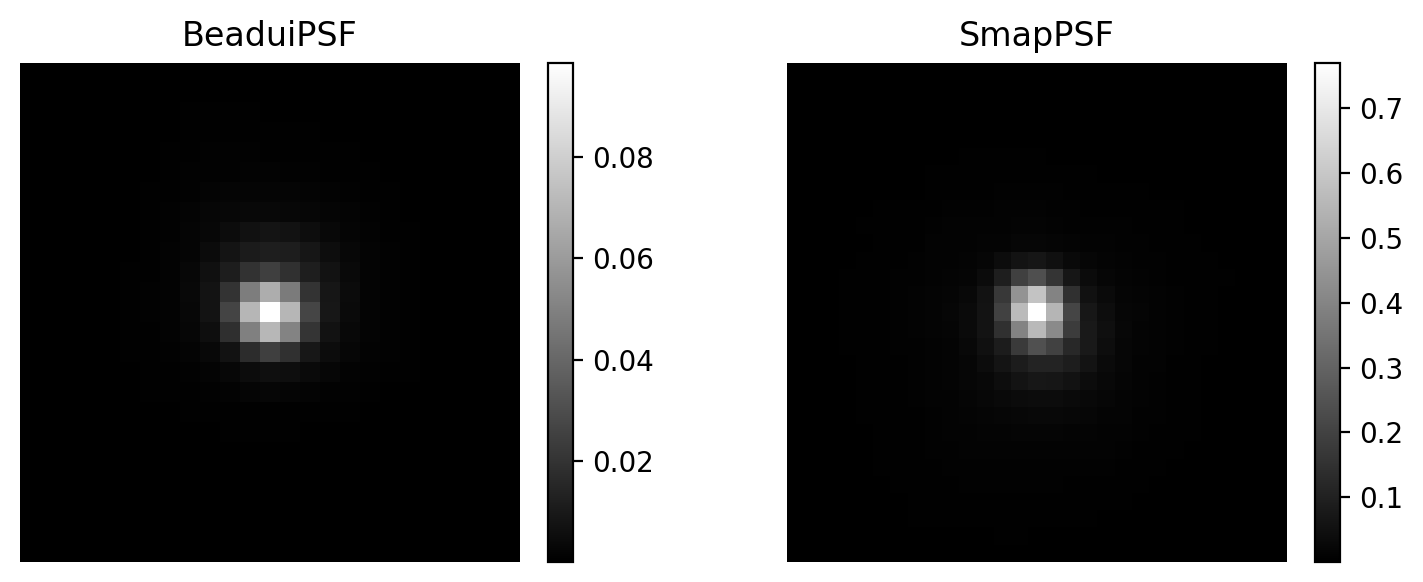

In [9]:
print(BeaduiPSF.res.channel1.I_model.shape)

CompPSF = [BeaduiPSF, SmapPSF]
title = ["BeaduiPSF", "SmapPSF"]
f, ax = plt.subplots(1, 2, figsize=(8, 3))
idx = [102, 102]

for i in range(2):
    img = CompPSF[i].res.channel0.I_model[idx[i], :, :] if i < 1 else CompPSF[i][0][idx[i], :, :] 
    
    print(img.sum())
    if hasattr(img, 'cpu'):
        img = img.cpu().numpy()

    im = ax[i].imshow(img, cmap='gray')
    ax[i].set_title(title[i])
    ax[i].axis("off")
    f.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)  # 添加 colorbar

plt.tight_layout()
plt.show()







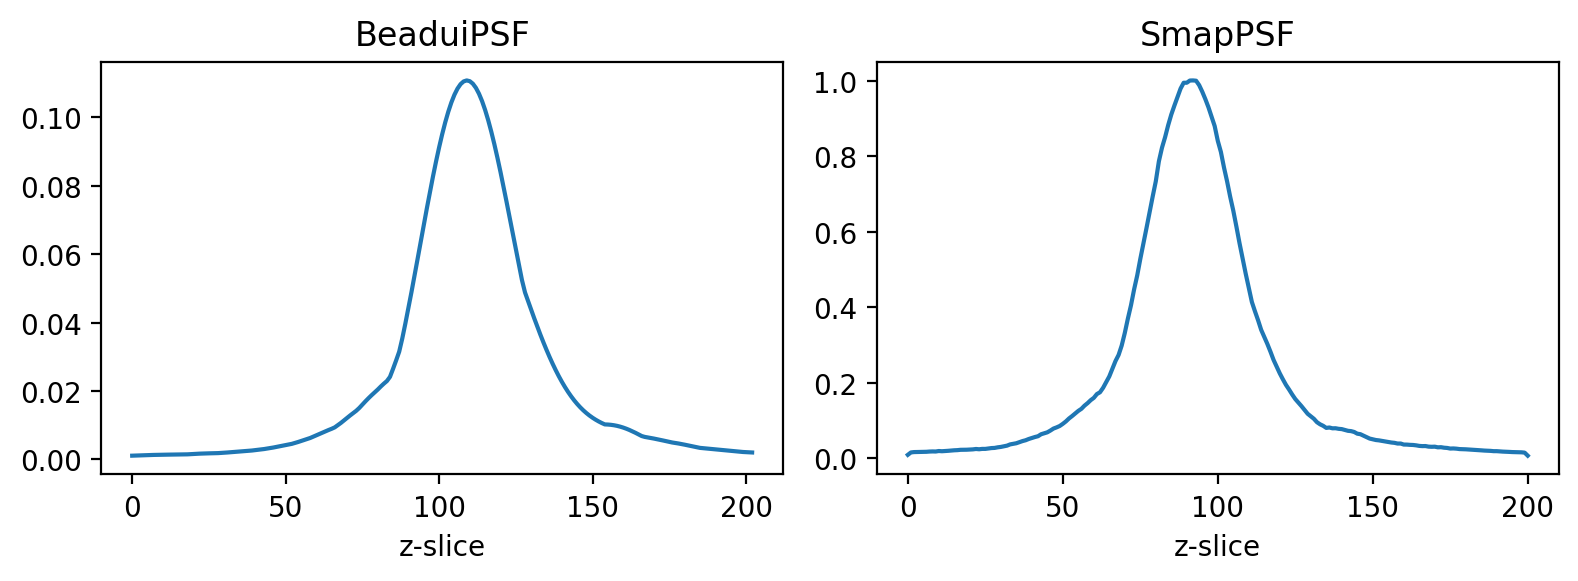

In [11]:

# CompPSF = [BeaduiPSF, insituPSF, GenPSF, SmapPSF]
# title = ["BeaduiPSF-r0", "GenPSF_stag0-r0", "GenPSF_stag0.5-r0", "GenPSF_stag1-r0"]
f, ax = plt.subplots(1, 2, figsize=(8, 3))

for i in range(2):
    img = CompPSF[i].res.channel0.I_model if i < 1 else CompPSF[i][0] 
    
    
    # if i == 0:
    #     img = img[72:133]
    
    # int_dist.append(img.sum(axis=(1,2)))
    
    ax[i].plot(img.max(axis=(1,2)))
    ax[i].set_title(title[i])
    ax[i].set_xlabel("z-slice")
    
    

plt.tight_layout()
plt.show()







In [59]:
from decode.io.trafo import load_trafo_h5

pos_fov=np.array([[0.,0.,0.],[0.,256.,0.],[512.,0.,0.],[512.,256.,0.]], dtype=np.float32)  # positions in the field of view

trafo_size_ref = 512
trafo_mirr_dim = 0

offset = [-5, -23, 0]
smap_trafo = decode.io.trafo.load_xyz_trafo(
    smapPSF_trafo,
    scale=1 / 1000.0,
    switch_xy=True,
    shift=(1.0, 1.0, 0.0),
    reference="trafo_inv_raw",
    device="cuda:0",
)
# roi_shift_xy = [0,2,0]
# shift = [float(s) for s in roi_shift_xy]
# smap_trafo = decode.simulation.trafo.pos.trafo.offset_trafo(smap_trafo, offset=shift)
t_mirr = decode.simulation.trafo.pos.trafo.XYZMirrorAt.from_frame_flip(
    trafo_size_ref,
    trafo_mirr_dim,
    device="cuda:0",
)
t_mirr = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(
    t_mirr,
    ch=1,
)
smap_trafo.append(t_mirr)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
    offset, device="cuda:0"
)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

# final trafo
smap_trafo.append(trafo_shift)
smap_trafo = smap_trafo.to("cpu")

########################################
offset = [0, -23, 0]
Insitu_trafo = decode.io.trafo.load_xyz_trafo(
    insituPSF_path,
    scale=1.0,
    switch_xy=True,
    shift=None,
    reference="trafo_inv_raw",
    device="cuda:0",
    reverse_trafo=True,
)
Insitu_trafo = decode.simulation.trafo.pos.trafo.offset_trafo(Insitu_trafo, offset=shift)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
    offset, device="cuda:0"
)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

# final trafo
Insitu_trafo.append(trafo_shift)
Insitu_trafo = Insitu_trafo.to("cpu")

########################################
offset = [0, -23, 0]
bead_trafo = decode.io.trafo.load_xyz_trafo(
    BeaduiPSF_path,
    scale=1.0,
    switch_xy=True,
    shift=None,
    reference="trafo_inv_raw",
    device="cuda:0",
    reverse_trafo=True,
)
bead_trafo = decode.simulation.trafo.pos.trafo.offset_trafo(bead_trafo, offset=shift)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZShiftTransformation(
    offset, device="cuda:0"
)
trafo_shift = decode.simulation.trafo.pos.trafo.XYZChanneledTransformation(trafo_shift, 1)

# final trafo
bead_trafo.append(trafo_shift)
bead_trafo = bead_trafo.to("cpu")



CompTrafo = [bead_trafo, Insitu_trafo, smap_trafo] 
for i in range(3):
    t = CompTrafo[i]

    xyz = t.forward(torch.tensor(pos_fov))
    
    print(xyz)

2025-08-04 15:54:26 [info     ] Running experimental function `load_xyz_trafo` tested=True
2025-08-04 15:54:26 [info     ] Running experimental function `load_xyz_trafo` tested=True
2025-08-04 15:54:30 [info     ] Running experimental function `load_xyz_trafo` tested=True
tensor([[[  0.0000,   0.0000,   0.0000],
         [-12.1748,   4.7028,   0.0000]],

        [[  0.0000, 256.0000,   0.0000],
         [ -2.5674, 260.6470,   0.0000]],

        [[512.0000,   0.0000,   0.0000],
         [500.4076, -14.5502,   0.0000]],

        [[512.0000, 256.0000,   0.0000],
         [510.0151, 241.3940,   0.0000]]])
tensor([[[  0.0000,   0.0000,   0.0000],
         [-12.2921,   4.4927,   0.0000]],

        [[  0.0000, 256.0000,   0.0000],
         [ -2.6781, 260.4964,   0.0000]],

        [[512.0000,   0.0000,   0.0000],
         [500.4077, -14.4012,   0.0000]],

        [[512.0000, 256.0000,   0.0000],
         [510.0217, 241.6025,   0.0000]]])
tensor([[[  0.0000,   0.0000,   0.0000],
         [-12.

In [60]:
t = CompTrafo[2]

xyz = t.forward(torch.tensor(pos_fov))

print(xyz)

tensor([[[  0.0000,   0.0000,   0.0000],
         [-12.4943,   4.7121,   0.0000]],

        [[  0.0000, 256.0000,   0.0000],
         [ -3.4937, 261.2885,   0.0000]],

        [[512.0000,   0.0000,   0.0000],
         [501.3225, -14.7588,   0.0000]],

        [[512.0000, 256.0000,   0.0000],
         [510.3231, 241.8176,   0.0000]]])
